# 04 — Parameter Tuning corrigé

Objectif :

1. Générer automatiquement un agent `my_agent_tuned.py`.
2. Tester sa validité avec `test_agent_validity.py`.
3. Évaluer plusieurs configurations via `evaluate_submission.py`.
4. Parser correctement les sorties officielles.
5. Exporter le meilleur agent vers `src/agents/my_agent.py`.

Corrections intégrées après lecture des outputs :
- la regex précédente ne reconnaissait pas les lignes du script officiel car elle utilisait `training_\\d+` au lieu de `training_\d+` ;
- les évaluations réussissaient mais étaient considérées comme échouées à cause du parsing ;
- `results`, `final_results` et `my_agent_path` sont maintenant toujours définis pour éviter les cascades de `NameError` ;
- la grille de tuning par défaut est volontairement réduite pour éviter les interruptions longues ;
- les sorties brutes sont sauvegardées pour debug.


## 1. Imports et détection robuste du dépôt

In [1]:

from pathlib import Path
import os
import sys
import subprocess
import time
import re
import json
import textwrap

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Si la détection automatique échoue, renseigne ici le chemin absolu du dépôt.
# Exemple Windows :
# MANUAL_REPO_ROOT = r"C:\\Users\\...\\stable_v2_RL_sailing_challenge"
MANUAL_REPO_ROOT = None


def safe_cwd():
    try:
        return Path.cwd().resolve()
    except FileNotFoundError:
        return Path.home().resolve()


def find_repo_root(manual_root=None):
    candidates = []

    if manual_root:
        candidates.append(Path(manual_root).expanduser().resolve())

    cwd = safe_cwd()
    candidates.extend([cwd] + list(cwd.parents))

    candidates.extend([
        Path("/mnt/data/stable_v2_RL_sailing_challenge"),
        Path("/mnt/data/sailing_repo/stable_v2_RL_sailing_challenge"),
        Path("/mnt/data/sailing/stable_v2_RL_sailing_challenge"),
        Path.home() / "stable_v2_RL_sailing_challenge",
    ])

    seen = set()
    for p in candidates:
        if p in seen:
            continue
        seen.add(p)

        if (p / "src" / "evaluate_submission.py").exists() and (p / "src" / "test_agent_validity.py").exists():
            return p

    raise FileNotFoundError(
        "Impossible de trouver le dépôt. "
        "Place ce notebook dans le dépôt ou renseigne MANUAL_REPO_ROOT."
    )


REPO_ROOT = find_repo_root(MANUAL_REPO_ROOT)
SRC_DIR = REPO_ROOT / "src"
AGENTS_DIR = SRC_DIR / "agents"
RESULTS_DIR = REPO_ROOT / "results"
RESULTS_DIR.mkdir(exist_ok=True)
AGENTS_DIR.mkdir(exist_ok=True)

print("REPO_ROOT  =", REPO_ROOT)
print("SRC_DIR    =", SRC_DIR)
print("AGENTS_DIR =", AGENTS_DIR)
print("RESULTS_DIR=", RESULTS_DIR)


REPO_ROOT  = /home/onyxia/work/stable_v2_RL_sailing_challenge
SRC_DIR    = /home/onyxia/work/stable_v2_RL_sailing_challenge/src
AGENTS_DIR = /home/onyxia/work/stable_v2_RL_sailing_challenge/src/agents
RESULTS_DIR= /home/onyxia/work/stable_v2_RL_sailing_challenge/results


## 2. Fonctions d'exécution robustes

In [2]:

def run_command(cmd, cwd=SRC_DIR, timeout=900):
    start = time.time()

    try:
        completed = subprocess.run(
            cmd,
            cwd=str(cwd),
            text=True,
            capture_output=True,
            timeout=timeout,
        )

        return {
            "cmd": " ".join(str(x) for x in cmd),
            "returncode": completed.returncode,
            "stdout": completed.stdout,
            "stderr": completed.stderr,
            "elapsed_sec": time.time() - start,
            "timeout": False,
            "error": None,
        }

    except subprocess.TimeoutExpired as e:
        return {
            "cmd": " ".join(str(x) for x in cmd),
            "returncode": -999,
            "stdout": e.stdout or "",
            "stderr": e.stderr or "",
            "elapsed_sec": time.time() - start,
            "timeout": True,
            "error": f"TimeoutExpired after {timeout} seconds",
        }


def print_result(res, max_chars=5000):
    print("CMD:", res["cmd"])
    print("Return code:", res["returncode"])
    print("Elapsed:", round(res["elapsed_sec"], 2), "sec")
    print("Timeout:", res["timeout"])
    if res["error"]:
        print("Error:", res["error"])

    print("\nSTDOUT:")
    print((res["stdout"] or "")[:max_chars])

    if res["stderr"]:
        print("\nSTDERR:")
        print(res["stderr"][:max_chars])


## 3. Parser correctement la sortie officielle

Le script officiel produit des lignes comme :

```text
training_1   | Success: 100.00% | Reward: 75.30 ± 0.18 | Steps: 57.6 ± 0.5
```

La correction principale est ici : utiliser `training_\d+` et non `training_\\d+`.


In [3]:

RESULT_RE = re.compile(
    r"(?P<scenario>training_\d+|test)\s*(?:\(TEST\))?\s*\|\s*"
    r"Success:\s*(?P<success>[0-9.]+)%\s*\|\s*"
    r"Reward:\s*(?P<reward>-?[0-9.]+)\s*±\s*(?P<std_reward>[0-9.]+)\s*\|\s*"
    r"Steps:\s*(?P<steps>[0-9.]+)\s*±\s*(?P<std_steps>[0-9.]+)"
)

OVERALL_RE = re.compile(
    r"OVERALL\s*\|\s*Success:\s*(?P<success>[0-9.]+)%\s*±\s*(?P<std_success>[0-9.]+)%"
)


def parse_eval_output(text):
    if isinstance(text, bytes):
        text = text.decode("utf-8", errors="replace")

    rows = []

    for line in text.splitlines():
        m = RESULT_RE.search(line)
        if not m:
            continue

        d = m.groupdict()
        rows.append({
            "scenario": d["scenario"],
            "success_rate": float(d["success"]) / 100.0,
            "mean_reward": float(d["reward"]),
            "std_reward": float(d["std_reward"]),
            "mean_steps": float(d["steps"]),
            "std_steps": float(d["std_steps"]),
        })

    return rows


# Test de parsing sur une sortie réelle observée dans le notebook précédent.
sample_output = """
training_1   | Success: 100.00% | Reward: 75.30 ± 0.18 | Steps: 57.6 ± 0.5
training_2   | Success: 100.00% | Reward: 80.85 ± 0.20 | Steps: 43.4 ± 0.5
training_3   | Success: 100.00% | Reward: 78.34 ± 4.15 | Steps: 50.0 ± 11.0
"""

test_rows = parse_eval_output(sample_output)
display(pd.DataFrame(test_rows))

assert len(test_rows) == 3, "Parser test failed."
print("Parser OK.")


,scenario,success_rate,mean_reward,std_reward,mean_steps,std_steps
0,training_1,1.0,75.30,0.18,57.6,0.5
1,training_2,1.0,80.85,0.20,43.4,0.5
2,training_3,1.0,78.34,4.15,50.0,11.0


Parser OK.


## 4. Template de l'agent tunable

Cet agent :
- ne fait pas d'apprentissage pendant l'évaluation ;
- lit l'observation complète ;
- simule localement la dynamique du bateau ;
- utilise des waypoints gauche/droite ;
- choisit une action via une fonction de score.

Il est donc compatible avec la règle Codabench : **pre-trained/fixed policy**.


In [21]:

AGENT_TEMPLATE = """
import numpy as np

try:
    from evaluator.base_agent import BaseAgent
except Exception:
    try:
        from agents.base_agent import BaseAgent
    except Exception:
        class BaseAgent:
            def reset(self): pass
            def seed(self, seed=None): pass


class MyAgent(BaseAgent):
    GRID = 128
    WIND_SIZE = GRID * GRID * 2
    WORLD_SIZE = GRID * GRID

    GOAL = np.array([64.0, 127.0], dtype=np.float32)

    DIRECTIONS = np.array([
        [0, 1],
        [1, 1],
        [1, 0],
        [1, -1],
        [0, -1],
        [-1, -1],
        [-1, 0],
        [-1, 1],
        [0, 0],
    ], dtype=np.float32)

    LEFT_WAYPOINTS = np.array([
        [28.0, 30.0],
        [23.0, 62.0],
        [27.0, 96.0],
        [48.0, 116.0],
        [64.0, 127.0],
    ], dtype=np.float32)

    RIGHT_WAYPOINTS = np.array([
        [100.0, 30.0],
        [105.0, 62.0],
        [101.0, 96.0],
        [80.0, 116.0],
        [64.0, 127.0],
    ], dtype=np.float32)

    def __init__(self):
        self.np_random = np.random.default_rng(0)
        self.side = None
        self.waypoint_index = 0

        self.horizon = __HORIZON__
        self.progress_weight = __PROGRESS_WEIGHT__
        self.waypoint_weight = __WAYPOINT_WEIGHT__
        self.north_speed_weight = __NORTH_SPEED_WEIGHT__
        self.goal_weight = __GOAL_WEIGHT__
        self.collision_penalty = __COLLISION_PENALTY__
        self.border_penalty = __BORDER_PENALTY__
        self.center_penalty = __CENTER_PENALTY__
        self.wp_radius = __WP_RADIUS__
        self.side_margin = __SIDE_MARGIN__
        self.stay_penalty = __STAY_PENALTY__
        self.south_penalty = __SOUTH_PENALTY__

    def seed(self, seed=None):
        self.np_random = np.random.default_rng(seed)

    def reset(self):
        self.side = None
        self.waypoint_index = 0

    def act(self, observation):
        obs = np.asarray(observation, dtype=np.float32)
        x, y, vx, vy, wx, wy = obs[:6]

        wind_field, world = self._extract_maps(obs)

        position = np.array([x, y], dtype=np.float32)

        candidate_waypoints = self._candidate_waypoints(position, wind_field)

        best_action = 0
        best_score = -1e30

        candidates = self._candidate_sequences()

        for waypoint in candidate_waypoints:
            for seq in candidates:
                score = self._simulate_sequence(
                    position=np.array([x, y], dtype=np.float32),
                    velocity=np.array([vx, vy], dtype=np.float32),
                    seq=seq,
                    wind_field=wind_field,
                    world=world,
                    waypoint=waypoint,
                )

                if score > best_score:
                    best_score = score
                    best_action = int(seq[0])

        return int(best_action)
    
    def _candidate_waypoints(self, position, wind_field):
        y = float(position[1])

        if y < 40:
            return [
                np.array([28.0, 35.0], dtype=np.float32),
                np.array([100.0, 35.0], dtype=np.float32),
                np.array([64.0, 65.0], dtype=np.float32),
            ]

        if y < 90:
            return [
                np.array([23.0, 92.0], dtype=np.float32),
                np.array([105.0, 92.0], dtype=np.float32),
                np.array([64.0, 105.0], dtype=np.float32),
            ]

        if y < 115:
            return [
                np.array([48.0, 116.0], dtype=np.float32),
                np.array([80.0, 116.0], dtype=np.float32),
                self.GOAL,
            ]

        return [self.GOAL]


    def _extract_maps(self, obs):
        wind_flat = obs[6:6 + self.WIND_SIZE]
        world_flat = obs[6 + self.WIND_SIZE:6 + self.WIND_SIZE + self.WORLD_SIZE]

        wind_field = wind_flat.reshape(self.GRID, self.GRID, 2)
        world = world_flat.reshape(self.GRID, self.GRID)

        return wind_field, world

    def _candidate_sequences(self):
        h = int(self.horizon)

        if h <= 1:
            return [[a] for a in range(9)]

        # Horizon 2 is fast enough and quite effective.
        if h == 2:
            useful = [0, 1, 2, 6, 7, 8]
            candidates = []

            for a in range(9):
                candidates.append([a, a])

            for a in range(9):
                for b in useful:
                    candidates.append([a, b])

            return self._deduplicate(candidates)

        # Horizon >= 3: reduced candidates to keep evaluation fast.
        useful = [0, 1, 2, 6, 7, 8]
        candidates = []

        for a in range(9):
            candidates.append([a] * h)

        for a in range(9):
            for b in useful:
                candidates.append([a] + [b] * (h - 1))

        motifs = [[1, 7], [7, 1], [0, 1], [0, 7], [1, 0], [7, 0]]
        for motif in motifs:
            seq = (motif * ((h + len(motif) - 1) // len(motif)))[:h]
            candidates.append(seq)

        return self._deduplicate(candidates)

    @staticmethod
    def _deduplicate(candidates):
        seen = set()
        out = []
        for seq in candidates:
            key = tuple(int(x) for x in seq)
            if key not in seen:
                seen.add(key)
                out.append(list(key))
        return out

    def _choose_side(self, wind_field):
        left = wind_field[15:112, 12:40, :]
        right = wind_field[15:112, 88:116, :]

        left_score = float(np.mean(left[..., 1]) - 0.10 * abs(np.mean(left[..., 0])))
        right_score = float(np.mean(right[..., 1]) - 0.10 * abs(np.mean(right[..., 0])))

        if abs(left_score - right_score) <= self.side_margin:
            wx_start = float(wind_field[0, 64, 0])
            return "RIGHT" if wx_start >= 0 else "LEFT"

        return "LEFT" if left_score > right_score else "RIGHT"

    def _waypoints(self):
        return self.LEFT_WAYPOINTS if self.side == "LEFT" else self.RIGHT_WAYPOINTS

    def _current_waypoint(self):
        wps = self._waypoints()
        return wps[min(self.waypoint_index, len(wps) - 1)]

    def _update_waypoint(self, position):
        wps = self._waypoints()

        if self.waypoint_index >= len(wps) - 1:
            return

        current = wps[self.waypoint_index]
        dist = np.linalg.norm(position - current)

        if dist <= self.wp_radius:
            self.waypoint_index += 1

        y = position[1]
        if y > 45 and self.waypoint_index < 1:
            self.waypoint_index = 1
        if y > 82 and self.waypoint_index < 2:
            self.waypoint_index = 2
        if y > 108 and self.waypoint_index < 3:
            self.waypoint_index = 3

    @staticmethod
    def _sailing_efficiency(boat_direction, wind_direction):
        wind_from = -wind_direction
        angle = np.arccos(np.clip(np.dot(wind_from, boat_direction), -1.0, 1.0))

        if angle < np.pi / 4:
            return 0.05
        if angle < np.pi / 2:
            return 0.5 + 0.5 * (angle - np.pi / 4) / (np.pi / 4)
        if angle < 3 * np.pi / 4:
            return 1.0

        eff = 1.0 - 0.5 * (angle - 3 * np.pi / 4) / (np.pi / 4)
        return max(0.5, eff)

    def _next_state(self, position, velocity, action, wind_field):
        x = int(np.clip(round(float(position[0])), 0, self.GRID - 1))
        y = int(np.clip(round(float(position[1])), 0, self.GRID - 1))

        wind = wind_field[y, x]
        direction = self.DIRECTIONS[int(action)].astype(np.float32)

        wind_norm = np.linalg.norm(wind)

        if wind_norm > 1e-12:
            wind_normalized = wind / wind_norm
            direction_norm = np.linalg.norm(direction)

            if direction_norm < 1e-12:
                direction_normalized = np.array([1.0, 0.0], dtype=np.float32)
            else:
                direction_normalized = direction / direction_norm

            eff = self._sailing_efficiency(direction_normalized, wind_normalized)
            theoretical_velocity = direction * eff * wind_norm * 0.4

            speed = np.linalg.norm(theoretical_velocity)
            if speed > 8.0:
                theoretical_velocity = theoretical_velocity / speed * 8.0

            new_velocity = theoretical_velocity + 0.3 * (velocity - theoretical_velocity)

            speed = np.linalg.norm(new_velocity)
            if speed > 8.0:
                new_velocity = new_velocity / speed * 8.0
        else:
            new_velocity = 0.3 * velocity

        # Match environment discretization.
        new_velocity = np.where(new_velocity < 0, np.ceil(new_velocity), np.floor(new_velocity)).astype(np.float32)

        new_position = position + new_velocity
        new_position = np.clip(new_position, [0, 0], [self.GRID - 1, self.GRID - 1]).astype(np.float32)

        return new_position, new_velocity

    def _collision(self, position, world):
        x = int(np.clip(round(float(position[0])), 0, self.GRID - 1))
        y = int(np.clip(round(float(position[1])), 0, self.GRID - 1))
        return bool(world[y, x] > 0.5)

    def _distance_to_island(self, position, world):
        x0 = int(np.clip(round(float(position[0])), 0, self.GRID - 1))
        y0 = int(np.clip(round(float(position[1])), 0, self.GRID - 1))

        # Local window approximation for speed.
        r = 10
        x1, x2 = max(0, x0-r), min(self.GRID, x0+r+1)
        y1, y2 = max(0, y0-r), min(self.GRID, y0+r+1)

        sub = world[y1:y2, x1:x2]
        ys, xs = np.where(sub > 0.5)

        if len(xs) == 0:
            return 999.0

        xs = xs + x1
        ys = ys + y1

        d2 = (xs - position[0])**2 + (ys - position[1])**2
        return float(np.sqrt(np.min(d2)))

    def _score_state(self, position, velocity, world, waypoint, action, step_in_rollout):
        dist_wp = np.linalg.norm(position - waypoint)
        dist_goal = np.linalg.norm(position - self.GOAL)

        score = 0.0
        score += self.progress_weight * position[1]
        score -= self.waypoint_weight * dist_wp
        score -= self.goal_weight * dist_goal
        score += self.north_speed_weight * velocity[1]

        if int(action) == 8:
            score -= self.stay_penalty

        if int(action) in [3, 4, 5]:
            score -= self.south_penalty

        if position[0] < 3 or position[0] > 124:
            score -= self.border_penalty

        if 34 <= position[0] <= 94 and 12 <= position[1] <= 92:
            score -= self.center_penalty

        dist_island = self._distance_to_island(position, world)
        if dist_island < 8:
            score -= 500.0 * (8.0 - dist_island)

        if self._collision(position, world):
            score -= self.collision_penalty

        if dist_goal < 1.5:
            score += 1_000_000.0 / (1 + step_in_rollout)

        return float(score)

    def _simulate_sequence(self, position, velocity, seq, wind_field, world, waypoint):
        score = 0.0
        pos = position.copy()
        vel = velocity.copy()

        previous_goal_dist = np.linalg.norm(pos - self.GOAL)

        for j, action in enumerate(seq):
            pos, vel = self._next_state(pos, vel, action, wind_field)

            if self._collision(pos, world):
                return -self.collision_penalty

            current_goal_dist = np.linalg.norm(pos - self.GOAL)
            score += 10.0 * (previous_goal_dist - current_goal_dist)
            previous_goal_dist = current_goal_dist

            score += self._score_state(pos, vel, world, waypoint, action, j)

        return float(score)
"""

print("Template loaded.")
print("Number of characters:", len(AGENT_TEMPLATE))


Template loaded.
Number of characters: 11485


## 5. Générer un agent à partir d'une configuration

In [ ]:

DEFAULT_PARAMS = {
    "horizon": 2,
    "progress_weight": 4.0,
    "waypoint_weight": 1.0,
    "north_speed_weight": 8.0,
    "goal_weight": 0.35,
    "collision_penalty": 500_000.0,
    "border_penalty": 2_000.0,
    "center_penalty": 20.0,
    "wp_radius": 14.0,
    "side_margin": 0.05,
    "stay_penalty": 200.0,
    "south_penalty": 300.0,
}


def render_agent_code(params):
    code = AGENT_TEMPLATE

    for key, value in params.items():
        placeholder = "__" + key.upper() + "__"
        code = code.replace(placeholder, repr(value))

    # Guard against unreplaced placeholders.
    unreplaced = re.findall(r"__[A-Z_]+__", code)
    if unreplaced:
        raise ValueError(f"Unreplaced placeholders: {sorted(set(unreplaced))}")

    return code


def write_agent(params, filename="my_agent_tuned.py"):
    path = AGENTS_DIR / filename
    code = render_agent_code(params)
    path.write_text(code, encoding="utf-8")
    return path


agent_path = write_agent(DEFAULT_PARAMS)
print("Agent written to:", agent_path)
print(agent_path.read_text(encoding="utf-8")[:800])


Agent written to: /home/onyxia/work/stable_v2_RL_sailing_challenge/src/agents/my_agent_tuned.py

import numpy as np

try:
    from evaluator.base_agent import BaseAgent
except Exception:
    try:
        from agents.base_agent import BaseAgent
    except Exception:
        class BaseAgent:
            def reset(self): pass
            def seed(self, seed=None): pass


class MyAgent(BaseAgent):
    GRID = 128
    WIND_SIZE = GRID * GRID * 2
    WORLD_SIZE = GRID * GRID

    GOAL = np.array([64.0, 127.0], dtype=np.float32)

    DIRECTIONS = np.array([
        [0, 1],
        [1, 1],
        [1, 0],
        [1, -1],
        [0, -1],
        [-1, -1],
        [-1, 0],
        [-1, 1],
        [0, 0],
    ], dtype=np.float32)

    LEFT_WAYPOINTS = np.array([
        [28.0, 30.0],
        [23.0, 62.0],
        [27.0, 96.0],
        [48.0, 116.0],
        [64.0, 127.0],
    ], dtype=np.floa


## 6. Valider l'agent avec le script officiel

In [33]:

def validate_agent(agent_path, timeout=180):
    res = run_command(
        ["python", "test_agent_validity.py", str(agent_path)],
        cwd=SRC_DIR,
        timeout=timeout,
    )
    return res


validity_res = validate_agent(agent_path)
print_result(validity_res)

if validity_res["returncode"] != 0:
    raise RuntimeError("L'agent ne passe pas test_agent_validity.py")
else:
    print("Agent validity OK.")


CMD: python test_agent_validity.py /home/onyxia/work/stable_v2_RL_sailing_challenge/src/agents/my_agent_tuned.py
Return code: 0
Elapsed: 2.52 sec
Timeout: False

STDOUT:
✨ Validating agent in: /home/onyxia/work/stable_v2_RL_sailing_challenge/src/agents/my_agent_tuned.py ✨

🤖 Agent: MyAgent

✅ SUCCESS: Your agent meets all requirements!

⚠️ Warnings (not required to fix, but recommended):
  1. Agent does not implement save() method
  2. Agent does not implement load() method


🎉 Your agent is ready for submission!
Run this command to test performance before submitting:
python src/evaluate_submission.py /home/onyxia/work/stable_v2_RL_sailing_challenge/src/agents/my_agent_tuned.py --seeds 1 --num-seeds 10

Agent validity OK.


## 7. Évaluer un agent et parser les résultats

In [35]:

def evaluate_agent_file(agent_file, num_seeds=5, start_seed=1, timeout=900):
    res = run_command(
        [
            "python", "evaluate_submission.py", str(agent_file),
            "--seeds", str(start_seed),
            "--num-seeds", str(num_seeds),
        ],
        cwd=SRC_DIR,
        timeout=timeout,
    )

    rows = parse_eval_output(res["stdout"])

    df = pd.DataFrame(rows)
    status = {
        "ok": (res["returncode"] == 0 and len(rows) > 0),
        "returncode": res["returncode"],
        "n_rows": len(rows),
        "timeout": res["timeout"],
        "elapsed_sec": res["elapsed_sec"],
        "cmd": res["cmd"],
        "stdout": res["stdout"],
        "stderr": res["stderr"],
    }

    return df, status


df_eval, status = evaluate_agent_file(agent_path, num_seeds=5, timeout=900)

print("Evaluation status:")
print(json.dumps({k: v for k, v in status.items() if k not in ["stdout", "stderr"]}, indent=2))

if len(df_eval) > 0:
    display(df_eval)
else:
    print("Parsing failed. Raw output:")
    print(status["stdout"])
    print(status["stderr"])


Evaluation status:
{
  "ok": true,
  "returncode": 0,
  "n_rows": 3,
  "timeout": false,
  "elapsed_sec": 91.00359058380127,
  "cmd": "python evaluate_submission.py /home/onyxia/work/stable_v2_RL_sailing_challenge/src/agents/my_agent_tuned.py --seeds 1 --num-seeds 5"
}


,scenario,success_rate,mean_reward,std_reward,mean_steps,std_steps
0,training_1,1.0,73.90,1.88,61.4,5.1
1,training_2,1.0,80.13,0.16,45.2,0.4
2,training_3,1.0,70.83,0.35,69.8,1.0


## 8. Résumé d'une configuration

In [25]:

def summarize_eval_df(df):
    if len(df) == 0:
        return {
            "avg_reward": np.nan,
            "min_reward": np.nan,
            "avg_success": np.nan,
            "min_success": np.nan,
            "avg_steps": np.nan,
            "max_steps": np.nan,
        }

    return {
        "avg_reward": float(df["mean_reward"].mean()),
        "min_reward": float(df["mean_reward"].min()),
        "avg_success": float(df["success_rate"].mean()),
        "min_success": float(df["success_rate"].min()),
        "avg_steps": float(df["mean_steps"].mean()),
        "max_steps": float(df["mean_steps"].max()),
    }


summary_eval = summarize_eval_df(df_eval)
print(json.dumps(summary_eval, indent=2))


{
  "avg_reward": 74.23,
  "min_reward": 69.99,
  "avg_success": 1.0,
  "min_success": 1.0,
  "avg_steps": 60.800000000000004,
  "max_steps": 72.2
}


## 9. Grille de tuning réduite et sûre

La précédente grille était trop large et a été interrompue.  
Ici, on commence petit, puis on élargit si tout fonctionne.

Tu peux augmenter `MAX_CONFIGS` et `NUM_SEEDS_FAST` une fois la boucle validée.


In [9]:

# Grille raisonnable : petite et rapide.
param_grid = []

for horizon in [2]:
    for waypoint_weight in [1.3, 1.6, 2.0]:
        for north_speed_weight in [5.0, 7.0]:
            for center_penalty in [60.0, 120.0]:
                params = {
                    **DEFAULT_PARAMS,
                    "horizon": horizon,
                    "waypoint_weight": waypoint_weight,
                    "north_speed_weight": north_speed_weight,
                    "center_penalty": center_penalty,
                }
                param_grid.append(params)

# Option : ajouter quelques candidats horizon=3, plus coûteux.
ADD_HORIZON_3_CANDIDATES = False
if ADD_HORIZON_3_CANDIDATES:
    for waypoint_weight in [1.6]:
        for north_speed_weight in [6.0]:
            for center_penalty in [80.0, 120.0]:
                param_grid.append({
                    **DEFAULT_PARAMS,
                    "horizon": 3,
                    "waypoint_weight": waypoint_weight,
                    "north_speed_weight": north_speed_weight,
                    "center_penalty": center_penalty,
                })

MAX_CONFIGS = len(param_grid)  # mets par exemple 4 pour tester vite.
param_grid = param_grid[:MAX_CONFIGS]

print("Number of configs:", len(param_grid))
display(pd.DataFrame(param_grid).head())


Number of configs: 12


,horizon,progress_weight,waypoint_weight,north_speed_weight,goal_weight,collision_penalty,border_penalty,center_penalty,wp_radius,side_margin,stay_penalty,south_penalty
0,2,4.0,1.3,5.0,0.35,500000.0,2000.0,60.0,14.0,0.05,200.0,300.0
1,2,4.0,1.3,5.0,0.35,500000.0,2000.0,120.0,14.0,0.05,200.0,300.0
2,2,4.0,1.3,7.0,0.35,500000.0,2000.0,60.0,14.0,0.05,200.0,300.0
3,2,4.0,1.3,7.0,0.35,500000.0,2000.0,120.0,14.0,0.05,200.0,300.0
4,2,4.0,1.6,5.0,0.35,500000.0,2000.0,60.0,14.0,0.05,200.0,300.0


## 10. Lancer le tuning

Cette cellule ne fait plus échouer tout le notebook si une configuration échoue.


In [10]:

NUM_SEEDS_FAST = 10
TIMEOUT_PER_CONFIG = 900

all_rows = []
raw_outputs = {}

for i, params in enumerate(param_grid):
    filename = f"agent_tune_{i:03d}.py"
    path = write_agent(params, filename=filename)

    print("\n" + "=" * 80)
    print(f"[{i:03d}] Evaluating {filename}")
    print(params)

    df, status = evaluate_agent_file(
        path,
        num_seeds=NUM_SEEDS_FAST,
        timeout=TIMEOUT_PER_CONFIG,
    )

    raw_outputs[filename] = {
        "params": params,
        "status": {k: v for k, v in status.items() if k not in ["stdout", "stderr"]},
        "stdout": status["stdout"],
        "stderr": status["stderr"],
    }

    summary = summarize_eval_df(df)

    row = {
        "config_id": i,
        "agent_file": str(path),
        "ok": bool(status["ok"]),
        "returncode": status["returncode"],
        "timeout": status["timeout"],
        "elapsed_sec": status["elapsed_sec"],
        **summary,
        **params,
    }

    all_rows.append(row)

    if status["ok"]:
        print(
            f"OK | reward={summary['avg_reward']:.2f} | "
            f"success={summary['avg_success']:.2%} | "
            f"steps={summary['avg_steps']:.1f}"
        )
    else:
        print("FAILED OR PARSING FAILED")
        print(status["stdout"][:1500])
        print(status["stderr"][:1500])

results = pd.DataFrame(all_rows)

if len(results) > 0:
    results = results.sort_values(
        ["ok", "avg_success", "avg_reward", "avg_steps"],
        ascending=[False, False, False, True],
    ).reset_index(drop=True)

display(results)

raw_path = RESULTS_DIR / "parameter_tuning_raw_outputs.json"
raw_path.write_text(json.dumps(raw_outputs, indent=2), encoding="utf-8")

results_path = RESULTS_DIR / "parameter_tuning_results.csv"
results.to_csv(results_path, index=False)

print("Saved:", results_path)
print("Saved:", raw_path)



[000] Evaluating agent_tune_000.py
{'horizon': 2, 'progress_weight': 4.0, 'waypoint_weight': 1.3, 'north_speed_weight': 5.0, 'goal_weight': 0.35, 'collision_penalty': 500000.0, 'border_penalty': 2000.0, 'center_penalty': 60.0, 'wp_radius': 14.0, 'side_margin': 0.05, 'stay_penalty': 200.0, 'south_penalty': 300.0}


OK | reward=69.24 | success=93.33% | steps=90.2

[001] Evaluating agent_tune_001.py
{'horizon': 2, 'progress_weight': 4.0, 'waypoint_weight': 1.3, 'north_speed_weight': 5.0, 'goal_weight': 0.35, 'collision_penalty': 500000.0, 'border_penalty': 2000.0, 'center_penalty': 120.0, 'wp_radius': 14.0, 'side_margin': 0.05, 'stay_penalty': 200.0, 'south_penalty': 300.0}
OK | reward=0.00 | success=0.00% | steps=500.0

[002] Evaluating agent_tune_002.py
{'horizon': 2, 'progress_weight': 4.0, 'waypoint_weight': 1.3, 'north_speed_weight': 7.0, 'goal_weight': 0.35, 'collision_penalty': 500000.0, 'border_penalty': 2000.0, 'center_penalty': 60.0, 'wp_radius': 14.0, 'side_margin': 0.05, 'stay_penalty': 200.0, 'south_penalty': 300.0}
OK | reward=73.91 | success=100.00% | steps=61.7

[003] Evaluating agent_tune_003.py
{'horizon': 2, 'progress_weight': 4.0, 'waypoint_weight': 1.3, 'north_speed_weight': 7.0, 'goal_weight': 0.35, 'collision_penalty': 500000.0, 'border_penalty': 2000.0, 'center_penalty': 120

,config_id,agent_file,ok,returncode,timeout,elapsed_sec,avg_reward,min_reward,avg_success,min_success,...,waypoint_weight,north_speed_weight,goal_weight,collision_penalty,border_penalty,center_penalty,wp_radius,side_margin,stay_penalty,south_penalty
0,6,/home/onyxia/work/stable_v2_RL_sailing_challen...,True,0,False,91.155835,74.540000,70.83,1.000000,1.0,...,1.6,7.0,0.35,500000.0,2000.0,60.0,14.0,0.05,200.0,300.0
1,10,/home/onyxia/work/stable_v2_RL_sailing_challen...,True,0,False,92.176669,74.506667,70.80,1.000000,1.0,...,2.0,7.0,0.35,500000.0,2000.0,60.0,14.0,0.05,200.0,300.0
2,2,/home/onyxia/work/stable_v2_RL_sailing_challen...,True,0,False,101.969851,73.913333,70.78,1.000000,1.0,...,1.3,7.0,0.35,500000.0,2000.0,60.0,14.0,0.05,200.0,300.0
3,4,/home/onyxia/work/stable_v2_RL_sailing_challen...,True,0,False,151.274359,69.833333,56.82,0.933333,0.8,...,1.6,5.0,0.35,500000.0,2000.0,60.0,14.0,0.05,200.0,300.0
4,8,/home/onyxia/work/stable_v2_RL_sailing_challen...,True,0,False,141.452682,69.833333,56.82,0.933333,0.8,...,2.0,5.0,0.35,500000.0,2000.0,60.0,14.0,0.05,200.0,300.0
5,0,/home/onyxia/work/stable_v2_RL_sailing_challen...,True,0,False,131.959837,69.243333,56.82,0.933333,0.8,...,1.3,5.0,0.35,500000.0,2000.0,60.0,14.0,0.05,200.0,300.0
6,1,/home/onyxia/work/stable_v2_RL_sailing_challen...,True,0,False,844.423957,0.000000,0.00,0.000000,0.0,...,1.3,5.0,0.35,500000.0,2000.0,120.0,14.0,0.05,200.0,300.0
7,3,/home/onyxia/work/stable_v2_RL_sailing_challen...,True,0,False,886.839745,0.000000,0.00,0.000000,0.0,...,1.3,7.0,0.35,500000.0,2000.0,120.0,14.0,0.05,200.0,300.0
8,5,/home/onyxia/work/stable_v2_RL_sailing_challen...,True,0,False,850.839955,0.000000,0.00,0.000000,0.0,...,1.6,5.0,0.35,500000.0,2000.0,120.0,14.0,0.05,200.0,300.0
9,7,/home/onyxia/work/stable_v2_RL_sailing_challen...,True,0,False,860.737793,0.000000,0.00,0.000000,0.0,...,1.6,7.0,0.35,500000.0,2000.0,120.0,14.0,0.05,200.0,300.0


Saved: /home/onyxia/work/stable_v2_RL_sailing_challenge/results/parameter_tuning_results.csv
Saved: /home/onyxia/work/stable_v2_RL_sailing_challenge/results/parameter_tuning_raw_outputs.json


## 11. Visualiser les résultats du tuning

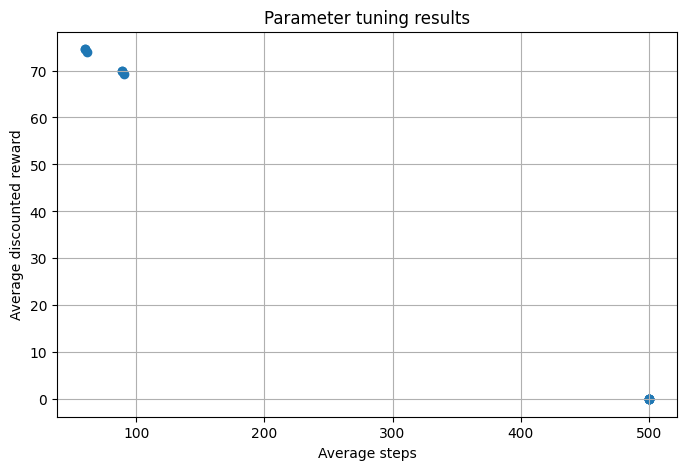

,config_id,avg_reward,avg_success,avg_steps,horizon,waypoint_weight,north_speed_weight,center_penalty,agent_file
0,6,74.540000,1.000000,59.933333,2,1.6,7.0,60.0,/home/onyxia/work/stable_v2_RL_sailing_challen...
1,10,74.506667,1.000000,60.033333,2,2.0,7.0,60.0,/home/onyxia/work/stable_v2_RL_sailing_challen...
2,2,73.913333,1.000000,61.666667,2,1.3,7.0,60.0,/home/onyxia/work/stable_v2_RL_sailing_challen...
3,4,69.833333,0.933333,88.566667,2,1.6,5.0,60.0,/home/onyxia/work/stable_v2_RL_sailing_challen...
4,8,69.833333,0.933333,88.566667,2,2.0,5.0,60.0,/home/onyxia/work/stable_v2_RL_sailing_challen...
5,0,69.243333,0.933333,90.200000,2,1.3,5.0,60.0,/home/onyxia/work/stable_v2_RL_sailing_challen...
6,1,0.000000,0.000000,500.000000,2,1.3,5.0,120.0,/home/onyxia/work/stable_v2_RL_sailing_challen...
7,3,0.000000,0.000000,500.000000,2,1.3,7.0,120.0,/home/onyxia/work/stable_v2_RL_sailing_challen...
8,5,0.000000,0.000000,500.000000,2,1.6,5.0,120.0,/home/onyxia/work/stable_v2_RL_sailing_challen...
9,7,0.000000,0.000000,500.000000,2,1.6,7.0,120.0,/home/onyxia/work/stable_v2_RL_sailing_challen...


In [11]:

if "results" not in globals() or len(results) == 0:
    print("No tuning results available.")
else:
    ok_results = results[results["ok"] == True].copy()

    if len(ok_results) == 0:
        print("No successful parsed configurations.")
    else:
        plt.figure(figsize=(8, 5))
        plt.scatter(ok_results["avg_steps"], ok_results["avg_reward"])
        plt.xlabel("Average steps")
        plt.ylabel("Average discounted reward")
        plt.title("Parameter tuning results")
        plt.grid(True)
        plt.show()

        cols = [
            "config_id", "avg_reward", "avg_success", "avg_steps",
            "horizon", "waypoint_weight", "north_speed_weight",
            "center_penalty", "agent_file",
        ]
        display(ok_results[cols].head(10))


## 12. Réévaluer les meilleurs candidats

On commence avec `NUM_SEEDS_FINAL = 20`.  
Avant une vraie soumission, passe à `50`.


In [12]:

TOP_K = 3
NUM_SEEDS_FINAL = 20
TIMEOUT_FINAL = 1800

final_rows = []
final_raw_outputs = {}

if "results" not in globals() or len(results) == 0:
    print("No results to re-evaluate.")
else:
    candidates = results[results["ok"] == True].head(TOP_K)

    if len(candidates) == 0:
        print("No successful candidates to re-evaluate.")
    else:
        for _, row in candidates.iterrows():
            config_id = int(row["config_id"])
            params = {k: row[k] for k in DEFAULT_PARAMS.keys()}
            params = {k: (int(v) if k == "horizon" else float(v)) for k, v in params.items()}

            path = write_agent(params, filename=f"agent_final_{config_id:03d}.py")

            print("\n" + "=" * 80)
            print("Final evaluation:", path.name)
            print(params)

            df, status = evaluate_agent_file(
                path,
                num_seeds=NUM_SEEDS_FINAL,
                timeout=TIMEOUT_FINAL,
            )

            final_raw_outputs[path.name] = {
                "params": params,
                "status": {k: v for k, v in status.items() if k not in ["stdout", "stderr"]},
                "stdout": status["stdout"],
                "stderr": status["stderr"],
            }

            summary = summarize_eval_df(df)

            final_rows.append({
                "config_id": config_id,
                "agent_file": str(path),
                "ok": bool(status["ok"]),
                "returncode": status["returncode"],
                "timeout": status["timeout"],
                "elapsed_sec": status["elapsed_sec"],
                **summary,
                **params,
            })

final_results = pd.DataFrame(final_rows)

if len(final_results) > 0:
    final_results = final_results.sort_values(
        ["ok", "avg_success", "avg_reward", "avg_steps"],
        ascending=[False, False, False, True],
    ).reset_index(drop=True)

display(final_results)

final_path = RESULTS_DIR / "parameter_tuning_final_results.csv"
final_raw_path = RESULTS_DIR / "parameter_tuning_final_raw_outputs.json"

final_results.to_csv(final_path, index=False)
final_raw_path.write_text(json.dumps(final_raw_outputs, indent=2), encoding="utf-8")

print("Saved:", final_path)
print("Saved:", final_raw_path)



Final evaluation: agent_final_006.py
{'horizon': 2, 'progress_weight': 4.0, 'waypoint_weight': 1.6, 'north_speed_weight': 7.0, 'goal_weight': 0.35, 'collision_penalty': 500000.0, 'border_penalty': 2000.0, 'center_penalty': 60.0, 'wp_radius': 14.0, 'side_margin': 0.05, 'stay_penalty': 200.0, 'south_penalty': 300.0}



Final evaluation: agent_final_010.py
{'horizon': 2, 'progress_weight': 4.0, 'waypoint_weight': 2.0, 'north_speed_weight': 7.0, 'goal_weight': 0.35, 'collision_penalty': 500000.0, 'border_penalty': 2000.0, 'center_penalty': 60.0, 'wp_radius': 14.0, 'side_margin': 0.05, 'stay_penalty': 200.0, 'south_penalty': 300.0}

Final evaluation: agent_final_002.py
{'horizon': 2, 'progress_weight': 4.0, 'waypoint_weight': 1.3, 'north_speed_weight': 7.0, 'goal_weight': 0.35, 'collision_penalty': 500000.0, 'border_penalty': 2000.0, 'center_penalty': 60.0, 'wp_radius': 14.0, 'side_margin': 0.05, 'stay_penalty': 200.0, 'south_penalty': 300.0}


,config_id,agent_file,ok,returncode,timeout,elapsed_sec,avg_reward,min_reward,avg_success,min_success,...,waypoint_weight,north_speed_weight,goal_weight,collision_penalty,border_penalty,center_penalty,wp_radius,side_margin,stay_penalty,south_penalty
0,6,/home/onyxia/work/stable_v2_RL_sailing_challen...,True,0,False,188.204360,74.626667,71.35,1.0,1.0,...,1.6,7.0,0.35,500000.0,2000.0,60.0,14.0,0.05,200.0,300.0
1,10,/home/onyxia/work/stable_v2_RL_sailing_challen...,True,0,False,197.310348,74.603333,71.33,1.0,1.0,...,2.0,7.0,0.35,500000.0,2000.0,60.0,14.0,0.05,200.0,300.0
2,2,/home/onyxia/work/stable_v2_RL_sailing_challen...,True,0,False,192.739526,73.993333,70.62,1.0,1.0,...,1.3,7.0,0.35,500000.0,2000.0,60.0,14.0,0.05,200.0,300.0


Saved: /home/onyxia/work/stable_v2_RL_sailing_challenge/results/parameter_tuning_final_results.csv
Saved: /home/onyxia/work/stable_v2_RL_sailing_challenge/results/parameter_tuning_final_raw_outputs.json


## 13. Exporter le meilleur agent comme `my_agent.py`

In [ ]:

def choose_best_row(final_results, results):
    if final_results is not None and len(final_results) > 0:
        ok = final_results[final_results["ok"] == True]
        if len(ok) > 0:
            return ok.iloc[0]

    if results is not None and len(results) > 0:
        ok = results[results["ok"] == True]
        if len(ok) > 0:
            return ok.iloc[0]

    return None


best = choose_best_row(final_results if "final_results" in globals() else None,
                       results if "results" in globals() else None)

if best is None:
    print("Aucun meilleur agent trouvé. On exporte DEFAULT_PARAMS par sécurité.")
    best_params = DEFAULT_PARAMS.copy()
else:
    best_params = {k: best[k] for k in DEFAULT_PARAMS.keys()}
    best_params = {k: (int(v) if k == "horizon" else float(v)) for k, v in best_params.items()}

my_agent_path = write_agent(best_params, filename="my_agent.py")

print("Best params:")
print(json.dumps(best_params, indent=2))
print("\nExported to:", my_agent_path)


Best params:
{
  "horizon": 2,
  "progress_weight": 4.0,
  "waypoint_weight": 1.6,
  "north_speed_weight": 7.0,
  "goal_weight": 0.35,
  "collision_penalty": 500000.0,
  "border_penalty": 2000.0,
  "center_penalty": 60.0,
  "wp_radius": 14.0,
  "side_margin": 0.05,
  "stay_penalty": 200.0,
  "south_penalty": 300.0
}

Exported to: /home/onyxia/work/stable_v2_RL_sailing_challenge/src/agents/my_agent.py


In [ ]:
# best_params = DEFAULT_PARAMS.copy()

# my_agent_path = write_agent(best_params, filename="my_agent.py")

# print("Exported DEFAULT_PARAMS as my_agent.py")
# print("Params:")
# print(json.dumps(best_params, indent=2))
# print("\nExported to:", my_agent_path)

Exported DEFAULT_PARAMS as my_agent.py
Params:
{
  "horizon": 2,
  "progress_weight": 4.0,
  "waypoint_weight": 1.6,
  "north_speed_weight": 8.0,
  "goal_weight": 0.35,
  "collision_penalty": 500000.0,
  "border_penalty": 2000.0,
  "center_penalty": 30.0,
  "wp_radius": 14.0,
  "side_margin": 0.05,
  "stay_penalty": 200.0,
  "south_penalty": 300.0
}

Exported to: /home/onyxia/work/stable_v2_RL_sailing_challenge/src/agents/my_agent.py


## 14. Validation finale locale

In [37]:

validity_res = validate_agent(my_agent_path)
print_result(validity_res)

if validity_res["returncode"] != 0:
    raise RuntimeError("my_agent.py ne passe pas test_agent_validity.py")

FINAL_NUM_SEEDS = 20  # Mets 50 avant soumission finale.
df_final, final_status = evaluate_agent_file(
    my_agent_path,
    num_seeds=FINAL_NUM_SEEDS,
    timeout=1800,
)

print("Final status:")
print(json.dumps({k: v for k, v in final_status.items() if k not in ["stdout", "stderr"]}, indent=2))

if len(df_final) > 0:
    display(df_final)
    print("Summary:")
    print(json.dumps(summarize_eval_df(df_final), indent=2))
else:
    print("Parsing failed. Raw output:")
    print(final_status["stdout"])
    print(final_status["stderr"])


CMD: python test_agent_validity.py /home/onyxia/work/stable_v2_RL_sailing_challenge/src/agents/my_agent.py
Return code: 0
Elapsed: 2.84 sec
Timeout: False

STDOUT:
✨ Validating agent in: /home/onyxia/work/stable_v2_RL_sailing_challenge/src/agents/my_agent.py ✨

🤖 Agent: MyAgent

✅ SUCCESS: Your agent meets all requirements!

⚠️ Warnings (not required to fix, but recommended):
  1. Agent does not implement save() method
  2. Agent does not implement load() method


🎉 Your agent is ready for submission!
Run this command to test performance before submitting:
python src/evaluate_submission.py /home/onyxia/work/stable_v2_RL_sailing_challenge/src/agents/my_agent.py --seeds 1 --num-seeds 10

Final status:
{
  "ok": true,
  "returncode": 0,
  "n_rows": 3,
  "timeout": false,
  "elapsed_sec": 345.6616473197937,
  "cmd": "python evaluate_submission.py /home/onyxia/work/stable_v2_RL_sailing_challenge/src/agents/my_agent.py --seeds 1 --num-seeds 20"
}


,scenario,success_rate,mean_reward,std_reward,mean_steps,std_steps
0,training_1,1.0,72.80,1.85,64.4,5.1
1,training_2,1.0,80.09,0.26,45.3,0.6
2,training_3,1.0,71.33,2.27,68.5,6.0


Summary:
{
  "avg_reward": 74.74,
  "min_reward": 71.33,
  "avg_success": 1.0,
  "min_success": 1.0,
  "avg_steps": 59.4,
  "max_steps": 68.5
}


## 15. Conseils pour la suite

Si les résultats sont mauvais :
- regarde `results/parameter_tuning_raw_outputs.json` ;
- augmente ou diminue `center_penalty` ;
- teste `horizon=3` seulement si le temps d'évaluation reste raisonnable ;
- utilise `06_visualize_failures.ipynb` pour voir les trajectoires ratées.

Si les résultats sont bons :
- passe à `05_compare_baselines.ipynb` ;
- puis à `07_build_submission.ipynb`.
